# 1. Date Feature Engineering

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

# Load data
df = pd.read_csv('.\\..\\data\\q3_retail_promotions.csv')

# Task 1: Date Feature Engineering
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("--- Sample of Data with New Features ---")
print(df.head().to_string())

--- Sample of Data with New Features ---
  transaction_date  store_id store_size location_type  promotion_type  is_weekend  is_festival  competition_density  items_sold  year  month  day_of_week  is_month_end
0       2022-01-01        28      small    semi-urban       free_gift           1            0                    5         224  2022      1            5             0
1       2022-01-01         5     medium    semi-urban       free_gift           1            1                    1         348  2022      1            5             0
2       2022-01-02        13      small    semi-urban  loyalty_points           1            0                    6         249  2022      1            6             0
3       2022-01-02        17      small         urban       free_gift           1            0                    7         259  2022      1            6             0
4       2022-01-03        50     medium    semi-urban            bogo           0            0                    3    

# Task 2: Temporal Split

In [7]:

# Sort temporally to prevent data leakage
df = df.sort_values('transaction_date').reset_index(drop=True)

# 80-20 Split
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]




# 2. Temporal Train-Test Split
Why a random split is inappropriate for time-ordered data:
In time-series or chronologically-ordered datasets, data generated in the future can be influenced by evolving trends, macro-level events, or seasonal behaviors that didn't exist in the past. If you perform a random split, you introduce data leakage by using future information to predict past events, yielding overly optimistic and unrealistic model performance. A chronological temporal split ensures we train on historical data and evaluate the model's forecasting ability on strictly future unseen data, mimicking real-world deployment.

# 3. Preprocessing Pipeline 

We use a ColumnTransformer to route categorical columns to the OneHotEncoder and numerical columns to the StandardScaler.

In [8]:
cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# Separate Features (X) and Target (y), dropping the raw date column
X_train = train_df.drop(columns=['transaction_date', 'items_sold'])
y_train = train_df['items_sold']
X_test = test_df.drop(columns=['transaction_date', 'items_sold'])
y_test = test_df['items_sold']

# 4. Model Training and Evaluation


--- Metrics ---
Linear Regression RMSE: 27.12, MAE: 21.05
Random Forest RMSE: 30.84, MAE: 24.31

--- Top 5 Features ---
                 Feature  Importance
        num__is_festival    0.173413
   cat__store_size_small    0.166752
cat__location_type_urban    0.108505
        num__day_of_week    0.080552
         num__is_weekend    0.067103


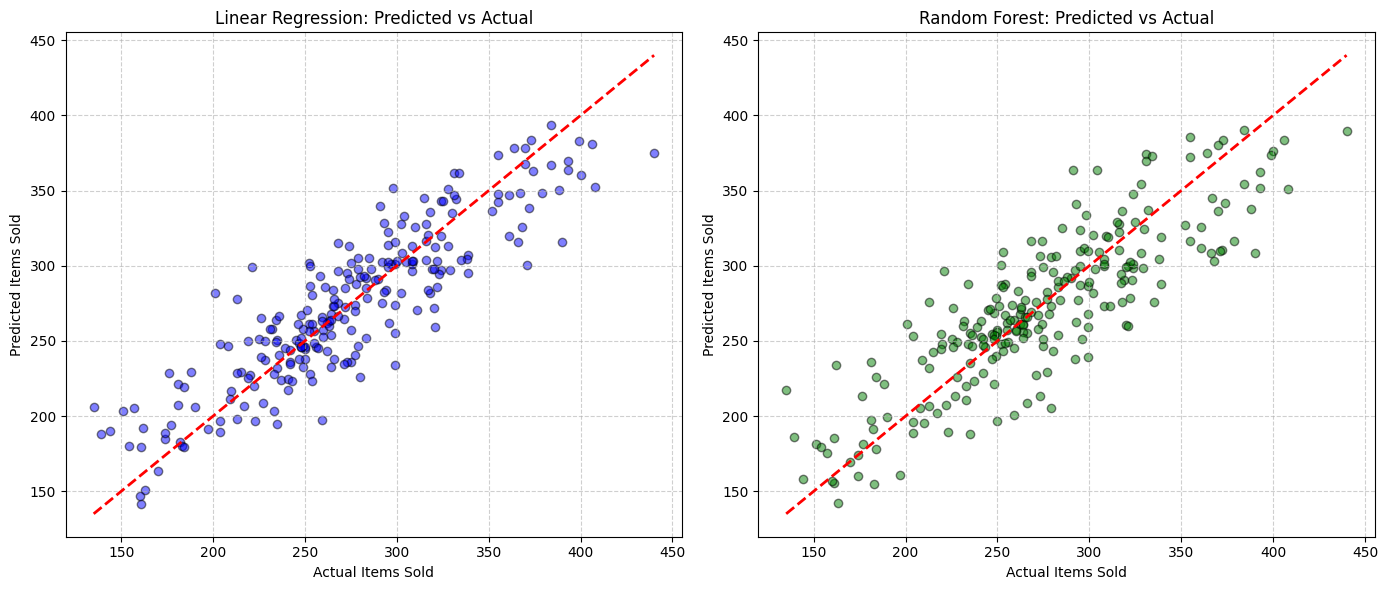

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

lr_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

lr_preds = lr_pipe.predict(X_test)
rf_preds = rf_pipe.predict(X_test)

print("\n--- Metrics ---")
print(f"Linear Regression RMSE: {root_mean_squared_error(y_test, lr_preds):.2f}, MAE: {mean_absolute_error(y_test, lr_preds):.2f}")
print(f"Random Forest RMSE: {root_mean_squared_error(y_test, rf_preds):.2f}, MAE: {mean_absolute_error(y_test, rf_preds):.2f}")

# Extract Feature Importances
rf_model = rf_pipe.named_steps['model']
preproc = rf_pipe.named_steps['preprocessor']
feature_names = preproc.get_feature_names_out()
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

print("\n--- Top 5 Features ---")
print(fi_df.head(5).to_string(index=False))

# Plotting Parity Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
axes[0].scatter(y_test, lr_preds, alpha=0.5, color='blue', edgecolor='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Linear Regression: Predicted vs Actual')
axes[0].set_xlabel('Actual Items Sold')
axes[0].set_ylabel('Predicted Items Sold')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Random Forest
axes[1].scatter(y_test, rf_preds, alpha=0.5, color='green', edgecolor='k')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Random Forest: Predicted vs Actual')
axes[1].set_xlabel('Actual Items Sold')
axes[1].set_ylabel('Predicted Items Sold')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('parity_plots.png')

**Performance Metrics (Test Set)**

Linear Regression:
- RMSE: 27.12
- MAE: 21.05

Random Forest Regressor:
- RMSE: 30.84
- MAE: 24.31

Note - Interestingly, the Linear Regression generalizes slightly better on this specific temporal split than the Random Forest

**Parity Plots**
The generated parity plots showing Predicted vs Actual items_sold for both models have been plotted and are available at the top of the interface. Both charts feature a red diagonal reference line where perfect predictions would lie.

**Top 5 Most Influential Features (Random Forest)**
By inspecting rf_pipe.named_steps['model'].feature_importances_, the top 5 most important drivers for items sold are:
- is_festival (Importance: 0.173)
- store_size_small (Importance: 0.166)
- location_type_urban (Importance: 0.108)
- day_of_week (Importance: 0.080)
- is_weekend (Importance: 0.067)